# 07 — Modélisation Prédictive

**Tâche :** Classification multiclasse de la gravité des accidents (Léger / Grave / Mortel)  
**Modèles :** Logistic Regression (baseline) · Random Forest · XGBoost · LightGBM  
**Pipeline :** Feature Engineering → Preprocessing → Tuning Optuna → Calibration → SHAP

---

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import learning_curve

from utils import load_dataframe, GRAVITE_COLORS, PATHS
from feature_engineering import run_feature_engineering
from modeling import (
    prepare_data, build_preprocessor, get_feature_lists,
    build_logistic_regression, build_random_forest, build_xgboost, build_lightgbm,
    evaluate_model, tune_lightgbm, compare_models,
    compute_shap_values, get_shap_importance,
    run_modeling_pipeline, CLASSES, RANDOM_STATE
)
from visualization import (
    plot_confusion_matrix, plot_feature_importance, plot_roc_curves
)

FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
print('Modules chargés ✓')

## 1. Feature Engineering

In [4]:
# Générer les features depuis les données nettoyées
df_feat = run_feature_engineering(
    clean_path=Path('../data/processed/accidents_clean.parquet'),
    save_path=Path('../data/processed/accidents_features.parquet')
)

print(f'\nFeatures créées : {df_feat.shape[1]} colonnes, {len(df_feat):,} lignes')

# Aperçu des nouvelles features
new_cols = [c for c in df_feat.columns if c not in [
    'accident_id', 'date_accident', 'gravite', 'gravite_num',
    'heure', 'jour_semaine', 'semestre', 'region', 'ville',
]]
print(f'Nouvelles features créées : {len(new_cols)}')
df_feat[new_cols[:15]].head(3)

2026-05-21 21:23:54 | INFO     | feature_engineering | ════════════════════════════════════════════════════════════
2026-05-21 21:23:54 | INFO     | feature_engineering | DÉMARRAGE DU FEATURE ENGINEERING
2026-05-21 21:23:54 | INFO     | feature_engineering | ════════════════════════════════════════════════════════════
2026-05-21 21:23:54 | INFO     | utils | DataFrame chargé ← ..\data\processed\accidents_clean.parquet (49,783 lignes)
2026-05-21 21:23:54 | INFO     | feature_engineering | [1/6] Features temporelles...
2026-05-21 21:23:54 | INFO     | feature_engineering |   Features temporelles créées ✓
2026-05-21 21:23:54 | INFO     | feature_engineering | [2/6] Features comportementales...
2026-05-21 21:23:54 | INFO     | feature_engineering |   Features comportementales créées ✓
2026-05-21 21:23:54 | INFO     | feature_engineering | [3/6] Features environnementales...
2026-05-21 21:23:54 | INFO     | feature_engineering |   Features environnementales créées ✓
2026-05-21 21:23:54 | IN


Features créées : 71 colonnes, 49,783 lignes
Nouvelles features créées : 62


,periode_journaliere,latitude,longitude,axe_routier,type_route,meteo,luminosite,type_vehicule,nombre_vehicules,nombre_victimes,nombre_deces,cause,etat_route,limitation_vitesse,vitesse_estimee
0,Nuit,7.516622,1.138084,Atakpamé-Sokodé,Nationale,Soleil,Nuit,Bus,2,2.0,0,Alcool,Bon,90,83.0
1,Nuit,6.232614,1.581350,Sokodé-Kara,Autoroute,Soleil,Nuit,Camion,1,1.0,0,Excès de vitesse,Bon,110,73.0
2,Soir,6.128474,1.240084,Sokodé-Kara,Nationale,Soleil,Nuit,Moto,3,2.0,2,Défaillance mécanique,Dégradé,90,83.0


## 2. Préparation Train/Test

2026-05-21 21:23:55 | INFO     | modeling |   Features numériques    : 52
2026-05-21 21:23:55 | INFO     | modeling |   Features catégorielles : 11


2026-05-21 21:23:56 | INFO     | modeling |   Train : 39,826 | Test : 9,957
2026-05-21 21:23:56 | INFO     | modeling |   Distribution y_train : [21310 10608  7908]
2026-05-21 21:23:56 | INFO     | modeling |   Distribution y_test  : [5328 2652 1977]


X_train : (39826, 63)
X_test  : (9957, 63)

Distribution y_train :
  Léger   : 21,310 (53.5%)
  Grave   : 10,608 (26.6%)
  Mortel  : 7,908 (19.9%)


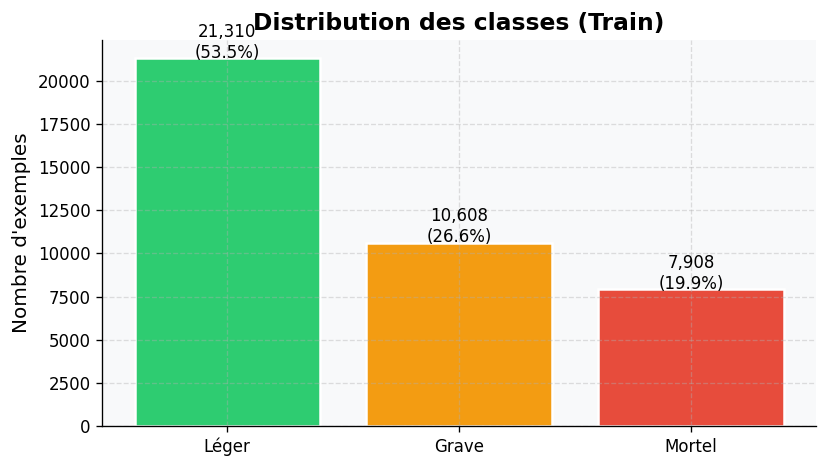

In [5]:
X_train, X_test, y_train, y_test, num_features, cat_features = prepare_data(df_feat)
preprocessor = build_preprocessor(num_features, cat_features)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nDistribution y_train :')
for i, cls in enumerate(CLASSES):
    n = (y_train == i).sum()
    print(f'  {cls:<8}: {n:,} ({n/len(y_train)*100:.1f}%)')

# Visualisation du déséquilibre
fig, ax = plt.subplots(figsize=(7, 4))
counts = [( y_train == i).sum() for i in range(3)]
colors = list(GRAVITE_COLORS.values())
bars = ax.bar(CLASSES, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{n:,}\n({n/sum(counts)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Distribution des classes (Train)', fontweight='bold')
ax.set_ylabel('Nombre d\'exemples')
plt.tight_layout()
plt.savefig(FIGURES / '07_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Baseline — Régression Logistique

2026-05-21 21:23:56 | INFO     | modeling | 
──────────────────────────────────────────────────
2026-05-21 21:23:56 | INFO     | modeling | Évaluation : Logistic Regression
2026-05-21 21:23:56 | INFO     | modeling | ──────────────────────────────────────────────────
2026-05-21 21:23:59 | INFO     | modeling |   F1-macro         : 0.9425
2026-05-21 21:23:59 | INFO     | modeling |   Balanced Accuracy: 0.9432
2026-05-21 21:23:59 | INFO     | modeling |   AUC-OvR (macro)  : 0.9932
2026-05-21 21:23:59 | INFO     | modeling | 
              precision    recall  f1-score   support

       Léger       1.00      1.00      1.00      5328
       Grave       0.93      0.92      0.93      2652
      Mortel       0.89      0.91      0.90      1977

    accuracy                           0.96      9957
   macro avg       0.94      0.94      0.94      9957
weighted avg       0.96      0.96      0.96      9957

2026-05-21 21:24:12 | INFO     | modeling |   CV F1-macro      : 0.9481 ± 0.0032
2026-05-2

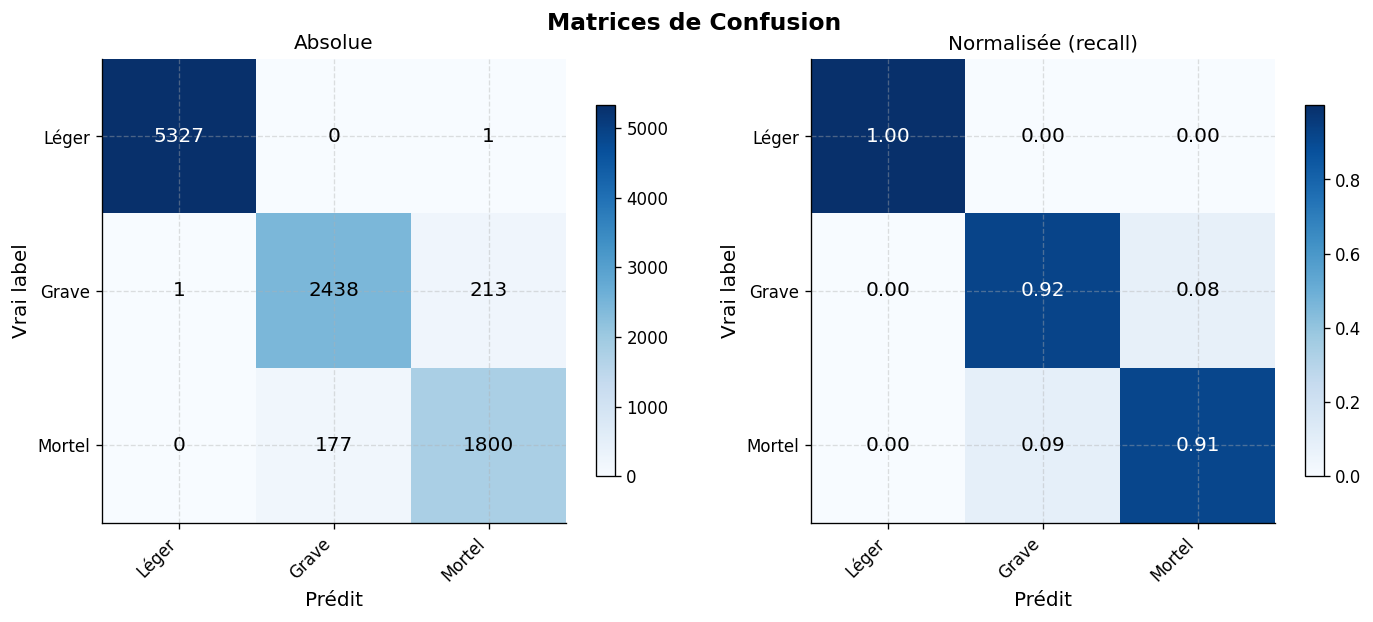

In [6]:
lr_pipe = build_logistic_regression(build_preprocessor(num_features, cat_features))
lr_result = evaluate_model(lr_pipe, X_train, X_test, y_train, y_test, 'Logistic Regression')

fig_cm = plot_confusion_matrix(
    lr_result['confusion_matrix'], CLASSES,
    FIGURES / '07_cm_logistic.png'
)
plt.show()

## 4. Random Forest

2026-05-21 21:24:13 | INFO     | modeling | 
──────────────────────────────────────────────────
2026-05-21 21:24:13 | INFO     | modeling | Évaluation : Random Forest
2026-05-21 21:24:13 | INFO     | modeling | ──────────────────────────────────────────────────
2026-05-21 21:24:22 | INFO     | modeling |   F1-macro         : 0.9885
2026-05-21 21:24:22 | INFO     | modeling |   Balanced Accuracy: 0.9883
2026-05-21 21:24:22 | INFO     | modeling |   AUC-OvR (macro)  : 0.9991
2026-05-21 21:24:22 | INFO     | modeling | 
              precision    recall  f1-score   support

       Léger       1.00      1.00      1.00      5328
       Grave       0.98      0.99      0.99      2652
      Mortel       0.98      0.98      0.98      1977

    accuracy                           0.99      9957
   macro avg       0.99      0.99      0.99      9957
weighted avg       0.99      0.99      0.99      9957

2026-05-21 21:24:58 | INFO     | modeling |   CV F1-macro      : 0.9876 ± 0.0023
2026-05-21 21:2

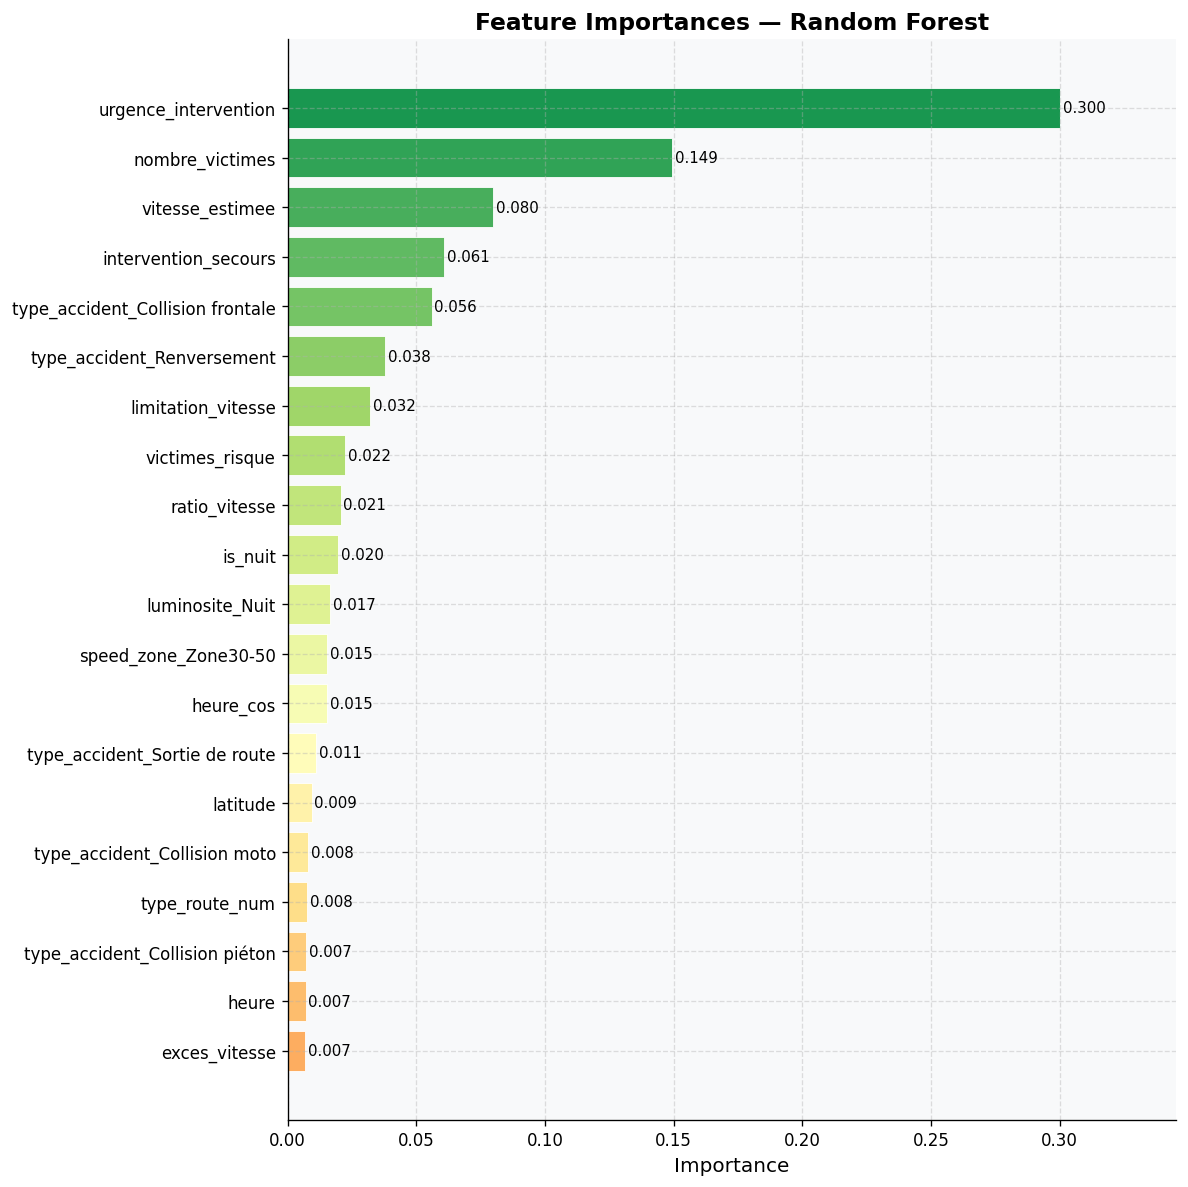

In [7]:
rf_pipe = build_random_forest(build_preprocessor(num_features, cat_features))
rf_result = evaluate_model(rf_pipe, X_train, X_test, y_train, y_test, 'Random Forest')

# Feature importance RF
rf_model = rf_pipe.named_steps['clf']
prep = rf_pipe.named_steps['prep']

try:
    feat_names = prep.get_feature_names_out()
except:
    feat_names = [f'f{i}' for i in range(len(rf_model.feature_importances_))]

importances = pd.Series(rf_model.feature_importances_, index=feat_names)

fig_imp = plot_feature_importance(
    importances, top_n=20,
    title='Feature Importances — Random Forest',
    save_path=FIGURES / '07_feature_importance_rf.png'
)
plt.show()

## 5. XGBoost

2026-05-21 21:25:00 | INFO     | modeling | 
──────────────────────────────────────────────────
2026-05-21 21:25:00 | INFO     | modeling | Évaluation : XGBoost
2026-05-21 21:25:00 | INFO     | modeling | ──────────────────────────────────────────────────
2026-05-21 21:25:21 | INFO     | modeling |   F1-macro         : 0.9943
2026-05-21 21:25:21 | INFO     | modeling |   Balanced Accuracy: 0.9941
2026-05-21 21:25:21 | INFO     | modeling |   AUC-OvR (macro)  : 0.9997
2026-05-21 21:25:21 | INFO     | modeling | 
              precision    recall  f1-score   support

       Léger       1.00      1.00      1.00      5328
       Grave       0.99      0.99      0.99      2652
      Mortel       0.99      0.99      0.99      1977

    accuracy                           1.00      9957
   macro avg       0.99      0.99      0.99      9957
weighted avg       1.00      1.00      1.00      9957

2026-05-21 21:26:15 | INFO     | modeling |   CV F1-macro      : 0.9954 ± 0.0018
2026-05-21 21:26:17 |

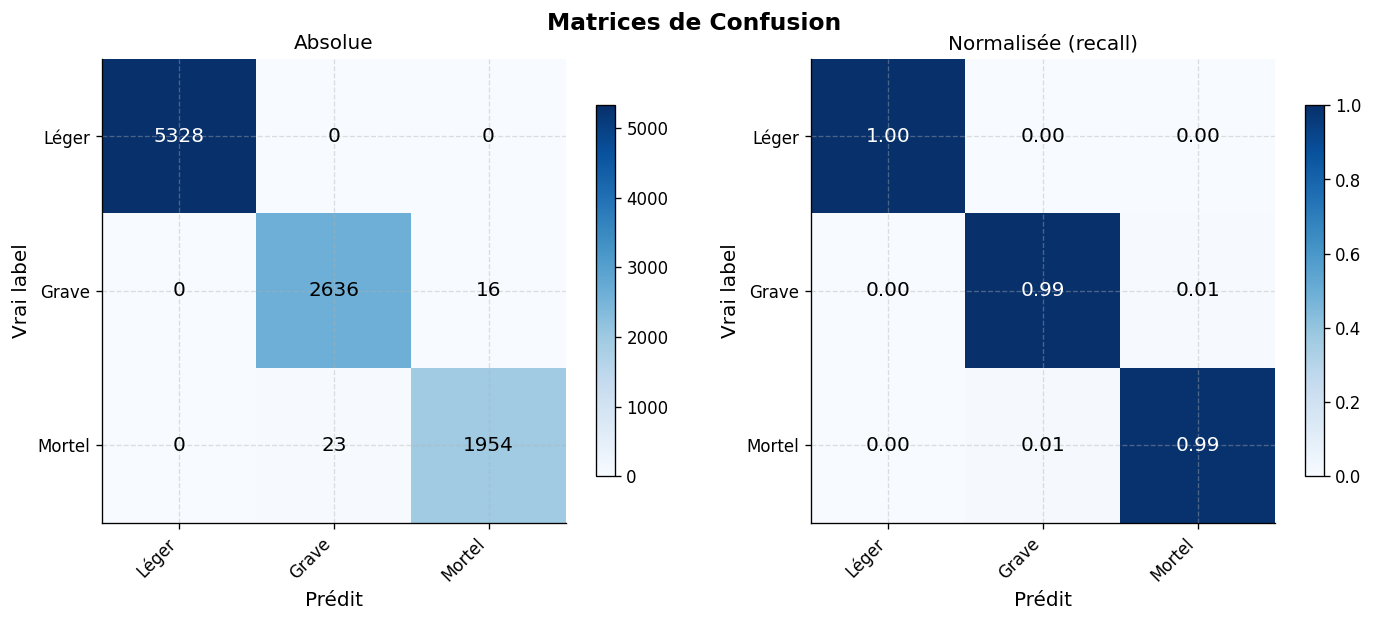

In [8]:
xgb_pipe = build_xgboost(build_preprocessor(num_features, cat_features))
xgb_result = evaluate_model(xgb_pipe, X_train, X_test, y_train, y_test, 'XGBoost')

fig_cm_xgb = plot_confusion_matrix(
    xgb_result['confusion_matrix'], CLASSES,
    FIGURES / '07_cm_xgboost.png'
)
plt.show()

## 6. LightGBM 

2026-05-21 21:26:18 | INFO     | modeling | 
──────────────────────────────────────────────────
2026-05-21 21:26:18 | INFO     | modeling | Évaluation : LightGBM
2026-05-21 21:26:19 | INFO     | modeling | ──────────────────────────────────────────────────
2026-05-21 21:26:41 | INFO     | modeling |   F1-macro         : 0.9940
2026-05-21 21:26:41 | INFO     | modeling |   Balanced Accuracy: 0.9939
2026-05-21 21:26:41 | INFO     | modeling |   AUC-OvR (macro)  : 0.9997
2026-05-21 21:26:41 | INFO     | modeling | 
              precision    recall  f1-score   support

       Léger       1.00      1.00      1.00      5328
       Grave       0.99      0.99      0.99      2652
      Mortel       0.99      0.99      0.99      1977

    accuracy                           1.00      9957
   macro avg       0.99      0.99      0.99      9957
weighted avg       1.00      1.00      1.00      9957

2026-05-21 21:27:23 | INFO     | modeling |   CV F1-macro      : 0.9950 ± 0.0020
2026-05-21 21:27:24 

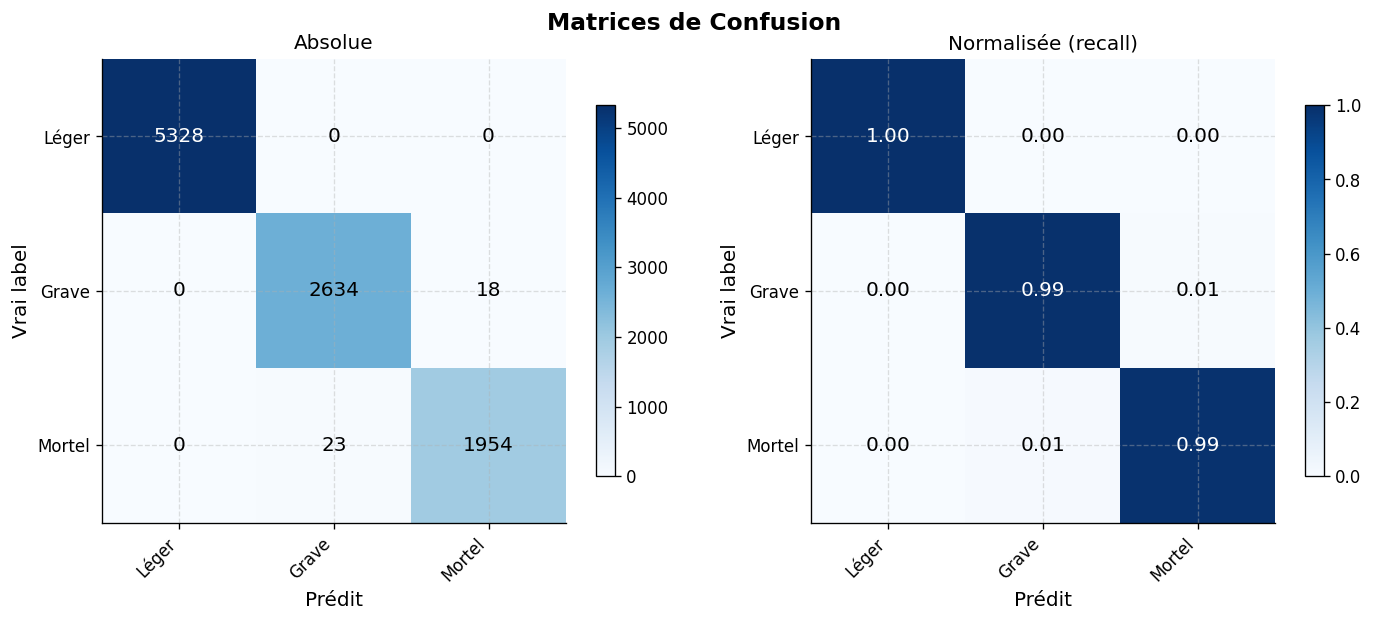

In [9]:
# Entraînement LightGBM de base (sans tuning pour reproductibilité rapide)
lgbm_pipe = build_lightgbm(build_preprocessor(num_features, cat_features))
lgbm_result = evaluate_model(lgbm_pipe, X_train, X_test, y_train, y_test, 'LightGBM')

fig_cm_lgbm = plot_confusion_matrix(
    lgbm_result['confusion_matrix'], CLASSES,
    FIGURES / '07_cm_lightgbm.png'
)
plt.show()

In [10]:
# ── Optuna Tuning LightGBM (décommenter pour l'exécuter) ─────────────────
# ATTENTION : prend ~10 min avec 50 trials

# best_lgbm_params = tune_lightgbm(
#     X_train, y_train,
#     build_preprocessor(num_features, cat_features),
#     n_trials=50
# )
# lgbm_tuned = build_lightgbm(build_preprocessor(num_features, cat_features), **best_lgbm_params)
# lgbm_tuned_result = evaluate_model(lgbm_tuned, X_train, X_test, y_train, y_test, 'LightGBM (tuned)')

## 7. Comparaison des modèles

═════════════════════════════════════════════════════════════════
COMPARAISON DES MODÈLES
═════════════════════════════════════════════════════════════════
             Modèle F1-macro (test) Balanced Acc. AUC-OvR CV F1 (mean±std)
            XGBoost          0.9943        0.9941  0.9997  0.9954 ± 0.0018
           LightGBM          0.9940        0.9939  0.9997  0.9950 ± 0.0020
      Random Forest          0.9885        0.9883  0.9991  0.9876 ± 0.0023
Logistic Regression          0.9425        0.9432  0.9932  0.9481 ± 0.0032


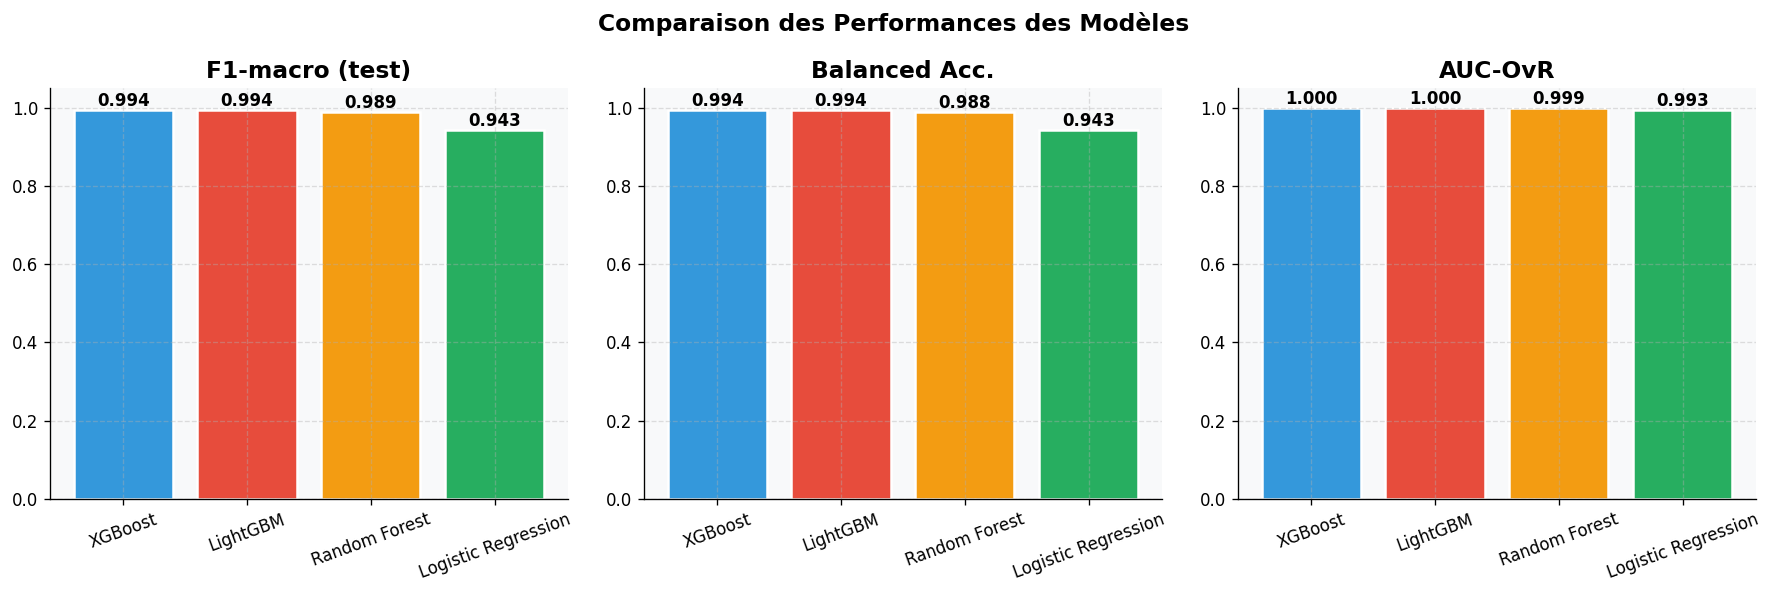

In [11]:
all_results = [lr_result, rf_result, xgb_result, lgbm_result]
comparison = compare_models(all_results)

print('═' * 65)
print('COMPARAISON DES MODÈLES')
print('═' * 65)
print(comparison.to_string(index=False))

# Graphique comparatif
metrics = ['F1-macro (test)', 'Balanced Acc.', 'AUC-OvR']
models  = comparison['Modèle'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison des Performances des Modèles', fontsize=14, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#f39c12', '#27ae60']
for ax, metric in zip(axes, metrics):
    values = [float(comparison[comparison['Modèle']==m][metric].values[0].split('±')[0]) for m in models]
    bars = ax.bar(models, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '07_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Courbes ROC

Meilleur modèle : XGBoost (F1=0.9943)


2026-05-21 21:27:29 | INFO     | visualization | Figure sauvegardée : ..\reports\figures\07_roc_xgboost.png


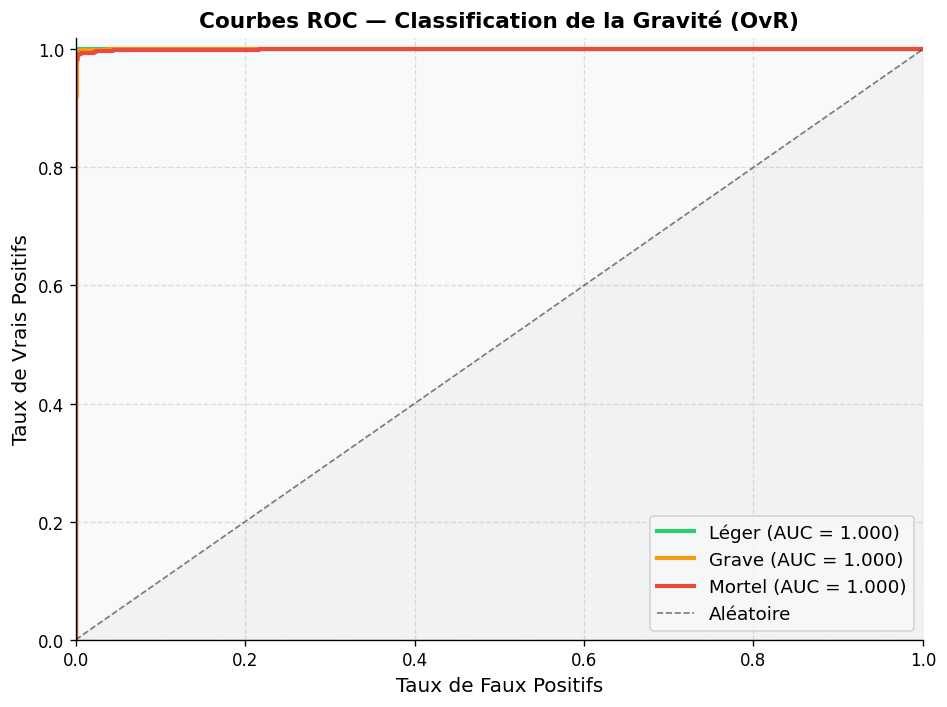

In [12]:
# Courbes ROC du meilleur modèle (LightGBM)
best_result = max(all_results, key=lambda r: r['f1_macro'])
print(f'Meilleur modèle : {best_result["model_name"]} (F1={best_result["f1_macro"]:.4f})')

fig_roc = plot_roc_curves(
    best_result['roc_data'],
    FIGURES / f'07_roc_{best_result["model_name"].replace(" ", "_").lower()}.png'
)
plt.show()

## 9. Courbes d'apprentissage

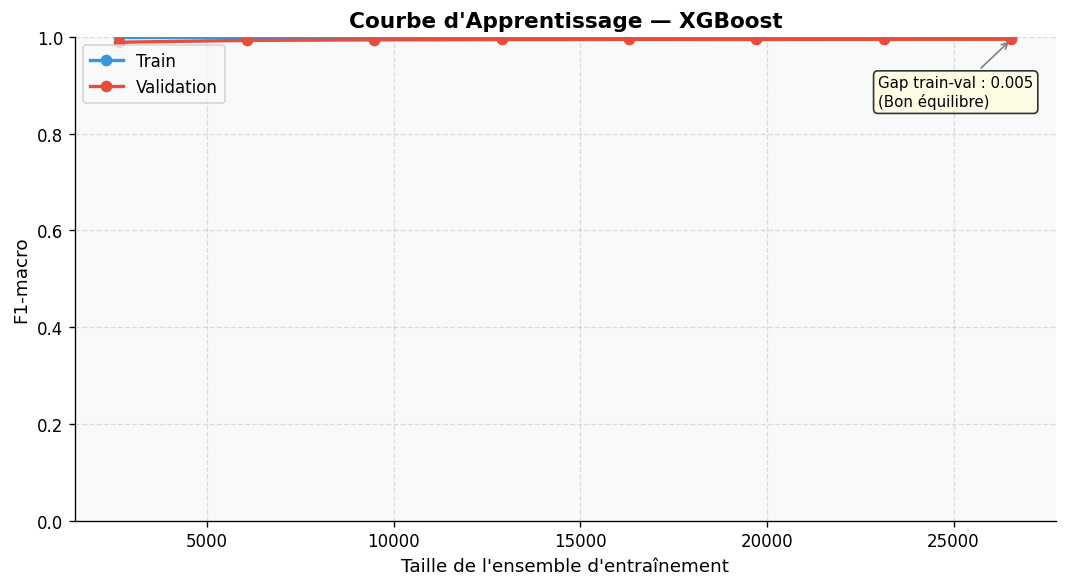

In [13]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

# Courbe d'apprentissage du meilleur modèle
train_sizes, train_scores, val_scores = learning_curve(
    best_result['pipeline'], X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Train')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', linewidth=2, label='Validation')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

ax.set_xlabel("Taille de l'ensemble d'entraînement", fontsize=11)
ax.set_ylabel('F1-macro', fontsize=11)
ax.set_title(f'Courbe d\'Apprentissage — {best_result["model_name"]}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)

# Annotation biais/variance
gap = train_mean[-1] - val_mean[-1]
ax.annotate(f'Gap train-val : {gap:.3f}\n({"Overfitting" if gap > 0.1 else "Bon équilibre"})',
            xy=(train_sizes[-1], val_mean[-1]), xytext=(-80, -40),
            textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray'),
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES / '07_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()